# Ajuste e seleção de modelos



---



Resumo dos Conceitos Fundamentais

#### Underfitting vs. Overfitting

O objetivo do aprendizado supervisionado NÃO é obter erro zero no treinamento.

O verdadeiro objetivo é:

> generalizar bem para dados novos.


**Underfitting (Sub-ajuste)**

Ocorre quando o modelo é simples demais para capturar os padrões dos dados.


Exemplo

Usar uma reta para modelar uma relação altamente curva.


*Consequências*

- erro alto no treino
- erro alto no teste
- modelo incapaz de aprender padrões relevantes


*Intuição*

```text
O modelo é simples demais
para o problema.
```

**Overfitting (Sobreajuste)**

Ocorre quando o modelo memoriza os dados de treinamento, incluindo ruídos.


*Consequências*

- erro muito baixo no treino
- erro alto no teste
- baixa capacidade de generalização

*Intuição*

```text
O modelo aprende o ruído
ao invés do padrão real.
```

Comparação Visual Mental

| Modelo | Comportamento |
|---|---|
| Underfitting | simples demais |
| Overfitting | complexo demais |
| Bom ajuste | equilíbrio |


#### O Dilema Viés-Variância (Bias-Variance Tradeoff)

O erro de previsão pode ser decomposto em:

$$
Erro =
Bias^2 +
Variância +
\sigma^2
$$

Onde:

- $Bias^2$ = erro sistemático
- Variância = sensibilidade aos dados
- $\sigma^2$ = erro irreduzível


**Viés (Bias)**

Representa simplificações excessivas do modelo.


*Alto viés gera:*

- underfitting
- previsões simplificadas
- incapacidade de capturar padrões

*Intuição*

```text
Modelo rígido demais.
```

**Variância**

Representa o quanto o modelo muda quando os dados de treino mudam levemente.

*Alta variância gera:*

- overfitting
- extrema sensibilidade aos dados
- baixa generalização

*Intuição*

```text
Modelo sensível demais.
```

**Equilíbrio Bias-Variance**

O objetivo do Machine Learning é encontrar o equilíbrio ideal.

*Intuição importante*

```text
Modelos simples:
↑ bias
↓ variância

Modelos complexos:
↓ bias
↑ variância
```

Vamos gerar os dados a partir uma função definida:

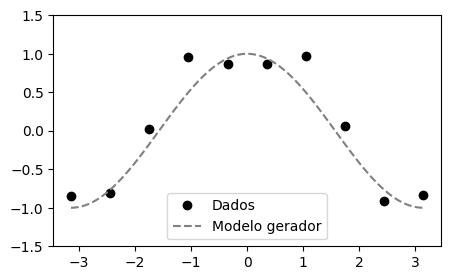

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
np.random.seed(42)

#função para gerar os dados
def gera_dados(x, sigma):
    y = np.cos(x) + np.random.normal(0, sigma, len(x))
    return y

# gera os dados de treinamento
n_train = 10
sigma = 0.3
min_X = -np.pi; max_X = np.pi
X_train= np.linspace(min_X,max_X,n_train)
y_train = gera_dados(X_train, sigma)
X_train = X_train.reshape(len(X_train), 1)

# mostra o conjunto de treinamento
plt.figure(figsize=(5,3))
plt.plot(X_train, y_train, color='black',
         marker = 'o', markersize=6,
         linestyle='none', label="Dados")

# mostra o modelo gerador dos dados
Xm = np.linspace(min_X,max_X,100)
yt = gera_dados(Xm, 0)
plt.plot(Xm,yt, color = 'gray',
         linestyle='--',  label="Modelo gerador")
plt.legend(fontsize = 10)
plt.ylim([-1.5, 1.5])
plt.show(True)

Vamos fazer o ajuste usando um polinômio de grau $M$.
$$
f(x,\theta) = \theta_0 + \theta_1 x + \theta_2 x^2 + \ldots + \theta_k x^M
$$
Inicialmente, vamos considerar $M=1$, ou seja, um ajuste linear.
$$
f(x,\theta) = \theta_0 + \theta_1 x
$$

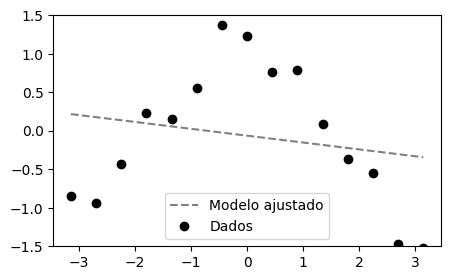

In [5]:
from sklearn import linear_model
from sklearn.preprocessing import PolynomialFeatures

# Define a matriz de atributos
poly3 = PolynomialFeatures(degree=1)
X = poly3.fit_transform(X_train)
# ajusta o modelo
model = linear_model.LinearRegression()
model.fit(X,y_train)
# mostra a curva obtida a partir da predição
xp = np.linspace(min_X,max_X,200)
Xplot = xp.reshape(len(xp), 1)
Xplot=poly3.fit_transform(Xplot)
# faz a predição
y_pred = model.predict(Xplot)
# mostra os resultados
plt.figure(figsize=(5,3))
plt.plot(xp, y_pred, color = 'gray',linestyle='--', label = 'Modelo ajustado')
plt.plot(X_train, y_train, color='black',
         marker = 'o', markersize=6,
         linestyle='none', label="Dados")
plt.legend(fontsize=10)
plt.ylim([-1.5, 1.5])
plt.show(True)

Notamos que, nesse caso, o ajuste é muito ruim, pois os dados foram gerados a partir de uma função não-linear. Esse fenômeno é chamado **underfitting** e ocorre quando o viíes (bias) é grande.

Vamos fazer o ajuste usando um polinômio de grau $M=3$.
$$
f(x,\theta) = \theta_0 + \theta_1 x + \theta_2 x^2 +  \theta_3 x^3
$$
Veja sobre a função para gerar o polinômio no link: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html

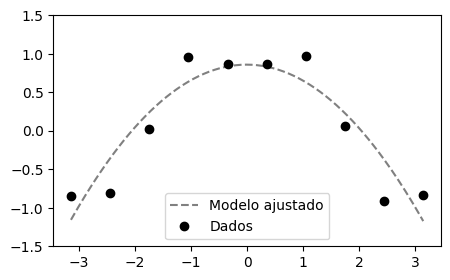

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
# Define a matriz de atributos
poly3 = PolynomialFeatures(degree=3)
X = poly3.fit_transform(X_train)
# ajusta o modelo
model = linear_model.LinearRegression()
model.fit(X,y_train)
# mostra a curva obtida a partir da predição
xp = np.linspace(min_X,max_X,200)
Xplot = xp.reshape(len(xp), 1)
Xplot=poly3.fit_transform(Xplot)
# faz a predição
y_pred = model.predict(Xplot)
# mostra os resultados
plt.figure(figsize=(5,3))
plt.plot(xp, y_pred, color = 'gray',linestyle='--', label = 'Modelo ajustado')
plt.plot(X_train, y_train, color='black',
         marker = 'o', markersize=6,
         linestyle='none', label="Dados")
plt.legend(fontsize=10)
plt.ylim([-1.5, 1.5])
plt.show(True)

Para um polinômio de grau maior:

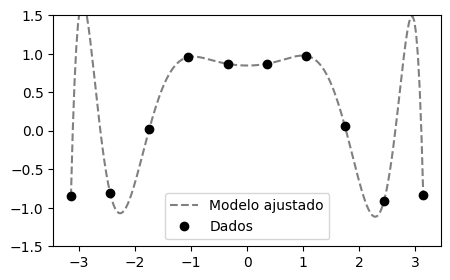

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
# Define a matriz de atributos
poly3 = PolynomialFeatures(degree=10)
X = poly3.fit_transform(X_train)
# ajusta o modelo
model = linear_model.LinearRegression()
model.fit(X,y_train)
# mostra a curva obtida a partir da predição
xp = np.linspace(min_X,max_X,200)
Xplot = xp.reshape(len(xp), 1)
Xplot=poly3.fit_transform(Xplot)
# faz a predição
y_pred = model.predict(Xplot)
# mostra os resultados
plt.figure(figsize=(5,3))
plt.plot(xp, y_pred, color = 'gray',linestyle='--', label = 'Modelo ajustado')
plt.plot(X_train, y_train, color='black',
         marker = 'o', markersize=6,
         linestyle='none', label="Dados")
plt.ylim([-1.5, 1.5])
plt.legend(fontsize=10)
plt.show(True)

Para um polinômio de grau $M=10$, a curva se ajusta a todos os pontos. Em princícipio, esse parece ser o melhor ajuste. No entanto, essa é uma indicação que o modelo está sobre-ajustado, de modo que consegue predizer o conjunto de treinamento perfeitamente. Ou seja, o modelo está memorizando os dados. Esse é um caso típico de **overfitting**.



O ajuste foi feito no conjunto de treinamento. Precisamos agora analisar a capacidade de generalização do modelo. Para isso, vamos fazer a previsão em novos dados, ou seja, no conjunto de teste.

Vamos analisar o erro na predição em função do grau do polinômio. O erro é calculando quando consideramos o conjunto de treinamento e teste, onde obtemos duas curvas distintas.

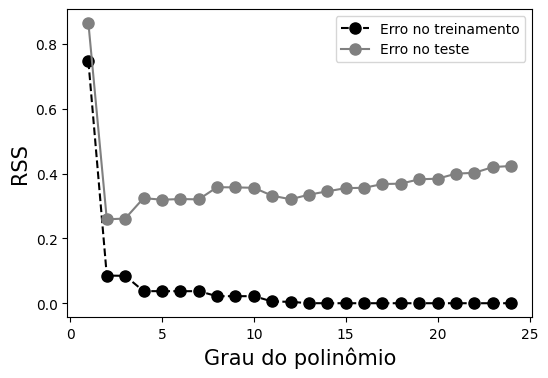

In [4]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from matplotlib import pyplot as plt
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
np.random.seed(42)

#função para gerar os dados
def gera_dados(x, sigma):
    y = np.cos(x) + np.random.normal(0, sigma, len(x))
    return y

# gera os dados de treinamento
n_train = 15; sigma = 0.3
min_X = -np.pi; max_X = np.pi
X_train= np.linspace(min_X,max_X,n_train)
y_train = gera_dados(X_train, sigma)
X_train = X_train.reshape(len(X_train), 1)

# gera os dados de teste
n_test = 10
X_test=np.linspace(0, 1,n_test)
y_test = gera_dados(X_test, sigma)
X_test = X_test.reshape(len(X_test), 1)

# lista que armazena os erros de acordo com o grau do polinomio
training_errors = []
test_errors = []
degree = [] # armazena os graus do polinomio
for k in np.arange(1,25):
    # transforma os dados para obter a matriz onde cada coluna i armazena x**i
    poly = PolynomialFeatures(degree=k)
    X_train_k = poly.fit_transform(X_train)
    # realiza a regressão linear no conjunto de treinamento
    # modelo a ser usado: regressão linear
    model = linear_model.LinearRegression()
    model.fit(X_train_k,y_train)
    y_pred = model.predict(X_train_k)
    error_train = mean_squared_error(y_train,y_pred)
    training_errors.append(error_train)

    # realiza a regressão linear no conjunto de teste
    X_test_k = poly.fit_transform(X_test)
    y_pred2 = model.predict(X_test_k)
    error_test = np.sqrt(mean_squared_error(y_test,y_pred2))
    test_errors.append(error_test)
    degree.append(k)
fig = plt.figure(figsize=(6,4))
plt.plot(degree, training_errors, marker = 'o',
         color = 'black', markersize=8,
         linestyle='--', label = 'Erro no treinamento')
plt.plot(degree, test_errors, marker = 'o',
         color = 'gray', markersize=8,
         linestyle='-', label= 'Erro no teste')
plt.xlabel("Grau do polinômio", fontsize = 15)
plt.ylabel("RSS", fontsize = 15)
plt.legend(fontsize = 10)
plt.show(True)

Notem que o erro na predição, quando usamos o conjunto de teste, tende a aumentar quando aumentamos o grau do polinômio, ou seja, quando aumentamos a complexidade do modelo. Essa é uma indicação de overfitting. Overfitting ocorre quando há um aumento no erro calculado no conjunto de teste, mas há uma alta taxa de acerto no conjunto de treinamento. Notem que o erro no conjunto de treinamento vai a zero quando aumentamos o grau do polinômio. Nesse caso, a curva se ajusta a todos os pontos, como vimos anteriormente para $M = 10$. Em resumo, dizemos que quando ocorre overfitting, o modelo está "memorizando" os dados e não "aprendendo", conforme o esperado.

Se aumentarmos o número de elementos no conjunto de treinamento, reduzimos o overfitting. Ou seja, precisamos balancear a complexidade do modelo de acordo com o volume de dados disponíveis. Vamos gerar os dados como anteriormente, mas com mais pontos.

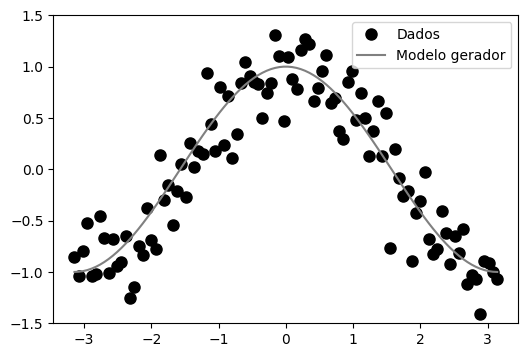

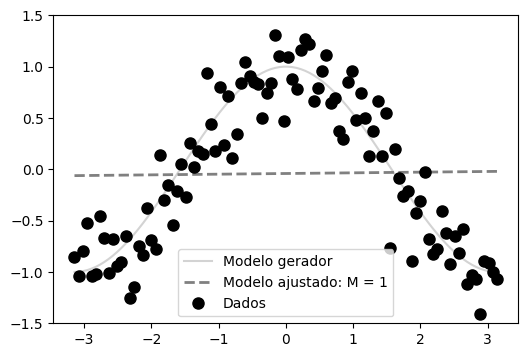

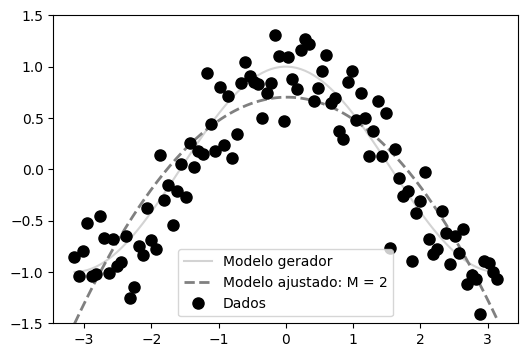

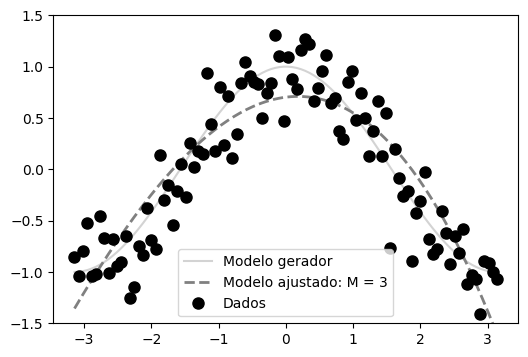

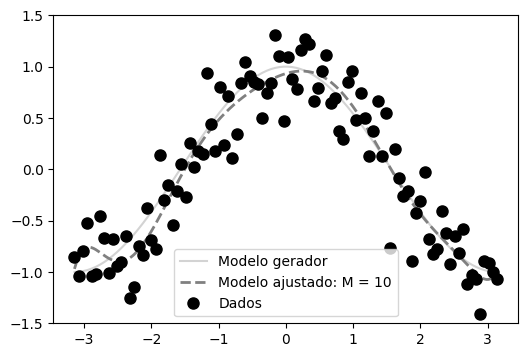

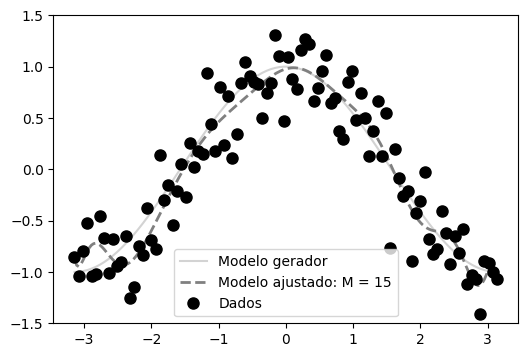

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model
np.random.seed(42)

#função para gerar os dados
def gera_dados(x, sigma):
    y = np.cos(x) + np.random.normal(0, sigma, len(x))
    return y

# gera os dados de treinamento
n_train = 100
sigma = 0.3
min_X = -np.pi; max_X = np.pi
X_train= np.linspace(min_X,max_X,n_train)
y_train = gera_dados(X_train, sigma)
X_train = X_train.reshape(len(X_train), 1)

# mostra o conjunto de treinamento
plt.figure(figsize=(6,4))
plt.plot(X_train, y_train, color='black',
         marker = 'o', markersize=8,
         linestyle='none', label="Dados")

# mostra o modelo gerador dos dados
Xm = np.linspace(min_X,max_X,100)
yt = gera_dados(Xm, 0)
plt.plot(Xm,yt, color = 'gray',
         linestyle='-',  label="Modelo gerador")
plt.legend(fontsize = 10)
plt.ylim([-1.5, 1.5])
plt.show(True)

# graus do polinômio
degrees = [1,2,3,10,15]
for dg in degrees:
    # Define a matriz de atributos
    poly3 = PolynomialFeatures(degree=dg)
    X = poly3.fit_transform(X_train)
    # ajusta o modelo
    model = linear_model.LinearRegression()
    model.fit(X,y_train)
    # mostra a curva obtida a partir da predição
    xp = np.linspace(min_X,max_X,200)
    Xplot = xp.reshape(len(xp), 1)
    Xplot=poly3.fit_transform(Xplot)
    # faz a predição
    y_pred = model.predict(Xplot)
    # mostra os resultados
    plt.figure(figsize=(6,4))
    plt.plot(Xm,yt, color = 'lightgray',
             linestyle='-',  label="Modelo gerador")

    plt.plot(xp, y_pred, color = 'gray',linestyle='--',
             linewidth = 2,
             label = 'Modelo ajustado: M = '+str(dg))
    plt.plot(X_train, y_train, color='black',
             marker = 'o', markersize=8,
             linestyle='none', label="Dados")
    plt.ylim([-1.5, 1.5])
    plt.legend(fontsize=10)
    plt.show(True)

Para um polinômio de grau $M=10$, vemos que com mais pontos, overfitting deixa de ocorrer.

Vamos analisar como o erro muda com o grau do polinômio:

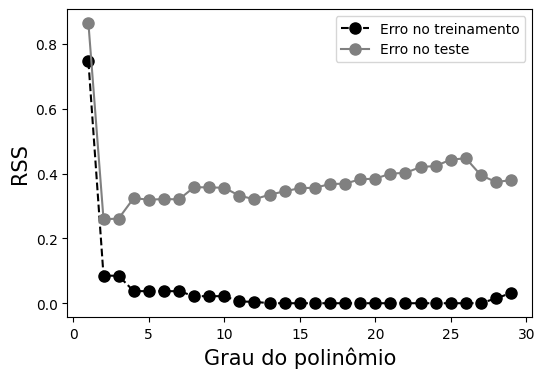

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error
np.random.seed(42)

#função para gerar os dados
def gera_dados(x, sigma):
    y = np.cos(x) + np.random.normal(0, sigma, len(x))
    return y

# gera os dados de treinamento
n_train = 15; sigma = 0.3
min_X = -np.pi; max_X = np.pi
X_train= np.linspace(min_X,max_X,n_train)
y_train = gera_dados(X_train, sigma)
X_train = X_train.reshape(len(X_train), 1)

# gera os dados de teste
n_test = 10
X_test=np.linspace(0, 1,n_test)
y_test = gera_dados(X_test, sigma)
X_test = X_test.reshape(len(X_test), 1)

# lista que armazena os erros de acordo com o grau do polinomio
training_errors = []
test_errors = []
degree = [] # armazena os graus do polinomio
for k in np.arange(1,30):
    # transforma os dados para obter a matriz onde cada coluna i armazena x**i
    poly = PolynomialFeatures(degree=k)
    X_train_k = poly.fit_transform(X_train)
    # realiza a regressão linear no conjunto de treinamento
    # modelo a ser usado: regressão linear
    model = linear_model.LinearRegression()
    model.fit(X_train_k,y_train)
    y_pred = model.predict(X_train_k)
    error_train = mean_squared_error(y_train,y_pred)
    training_errors.append(error_train)

    # realiza a regressão linear no conjunto de teste
    X_test_k = poly.fit_transform(X_test)
    y_pred2 = model.predict(X_test_k)
    error_test = np.sqrt(mean_squared_error(y_test,y_pred2))
    test_errors.append(error_test)
    degree.append(k)
fig = plt.figure(figsize=(6,4))
plt.plot(degree, training_errors, marker = 'o',
         color = 'black', markersize=8,
         linestyle='--', label = 'Erro no treinamento')
plt.plot(degree, test_errors, marker = 'o',
         color = 'gray', markersize=8,
         linestyle='-', label= 'Erro no teste')
plt.xlabel("Grau do polinômio", fontsize = 15)
plt.ylabel("RSS", fontsize = 15)
plt.legend(fontsize = 10)
plt.show(True)

Aumentando a quantidade de dados.

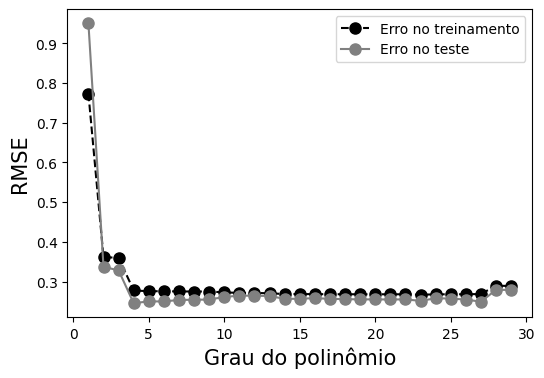

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error
np.random.seed(42)

#função para gerar os dados
def gera_dados(x, sigma):
    y = np.cos(x) + np.random.normal(0, sigma, len(x))
    return y

# gera os dados de treinamento
n_train = 150; sigma = 0.3
min_X = -np.pi; max_X = np.pi
X_train= np.linspace(min_X,max_X,n_train)
y_train = gera_dados(X_train, sigma)
X_train = X_train.reshape(len(X_train), 1)

# gera os dados de teste
n_test = 10
X_test=np.linspace(0, 1,n_test)
y_test = gera_dados(X_test, sigma)
X_test = X_test.reshape(len(X_test), 1)

# lista que armazena os erros de acordo com o grau do polinomio
training_errors = []
test_errors = []
degree = [] # armazena os graus do polinomio
for k in np.arange(1,30):
    # transforma os dados para obter a matriz onde cada coluna i armazena x**i
    poly = PolynomialFeatures(degree=k)
    X_train_k = poly.fit_transform(X_train)
    # realiza a regressão linear no conjunto de treinamento
    # modelo a ser usado: regressão linear
    model = linear_model.LinearRegression()
    model.fit(X_train_k,y_train)
    y_pred = model.predict(X_train_k)
    error_train = np.sqrt(mean_squared_error(y_train,y_pred))
    training_errors.append(error_train)

    # realiza a regressão linear no conjunto de teste
    X_test_k = poly.fit_transform(X_test)
    y_pred2 = model.predict(X_test_k)
    error_test = np.sqrt(mean_squared_error(y_test,y_pred2))
    test_errors.append(error_test)
    degree.append(k)
fig = plt.figure(figsize=(6,4))
plt.plot(degree, training_errors, marker = 'o',
         color = 'black', markersize=8,
         linestyle='--', label = 'Erro no treinamento')
plt.plot(degree, test_errors, marker = 'o',
         color = 'gray', markersize=8,
         linestyle='-', label= 'Erro no teste')
plt.xlabel("Grau do polinômio", fontsize = 15)
plt.ylabel("RMSE", fontsize = 15)
plt.legend(fontsize = 10)
plt.show(True)

## Regularização

Regularização adiciona penalidades à função de custo para controlar a complexidade do modelo.

Objetivo

Evitar coeficientes muito grandes:

$$
\beta_1, \beta_2, ..., \beta_n
$$

Podemo resolver o problema de overfitting usando regularização. Vamos considerar novamente o ajuste de um polinômio de grau 20. Na regularização Lasso:

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.430e-01, tolerance: 1.235e-03
  model = cd_fast.enet_coordinate_descent(


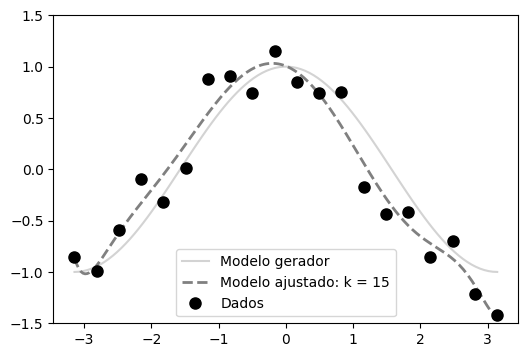

[ 0.00000000e+00 -2.58734484e-01 -6.32257802e-01  3.59129072e-02
  8.39373648e-02  7.75240958e-04 -2.50246259e-03 -1.13704995e-04
 -3.24841823e-04 -6.79310318e-06 -1.05945945e-05 -4.90697065e-07
  7.86847683e-07 -3.47789309e-08  1.82372095e-07 -1.20544115e-09]


In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

np.random.seed(42)

#função para gerar os dados
def gera_dados(x, sigma):
    y = np.cos(x) + np.random.normal(0, sigma, len(x))
    return y

# gera os dados de treinamento
n_train = 20
sigma = 0.3
min_X = -np.pi; max_X = np.pi
X_train= np.linspace(min_X,max_X,n_train)
y_train = gera_dados(X_train, sigma)
X_train = X_train.reshape(len(X_train), 1)

k = 15 # grau do polinômio
# Define a matriz de atributos
poly3 = PolynomialFeatures(degree=k)
X = poly3.fit_transform(X_train)
# ajusta o modelo usando Lasso
model = Lasso(alpha = 0.001)
model.fit(X,y_train)

# calcula a curva de predição
xp = np.linspace(min_X,max_X,200)
Xplot = xp.reshape(len(xp), 1)
Xplot=poly3.fit_transform(Xplot)
# faz a predição
y_pred = model.predict(Xplot)

# mostra os resultados
# o modelo gerador dos dados
Xm = np.linspace(min_X,max_X,100)
yt = gera_dados(Xm, 0)
plt.figure(figsize=(6,4))
plt.plot(Xm,yt, color = 'lightgray', linestyle='-',
         label="Modelo gerador")
# modelo ajustado
plt.plot(xp, y_pred, color = 'gray',linestyle='--',
         linewidth = 2,
         label = 'Modelo ajustado: k = '+str(k))
# mostra os dados
plt.plot(X_train, y_train, color='black', marker = 'o',
         markersize=8, linestyle='none', label="Dados")
plt.ylim([-1.5, 1.5])
plt.legend(fontsize=10)
plt.savefig('lasso.svg')
plt.show(True)

print(model.coef_)

Também podemos fazer a regulariação usando **Ridge Regression:**

Adiciona a soma dos quadrados dos coeficientes.

Fórmula

$$
RSS +
\lambda
\sum_{j=1}^{p}
\beta_j^2
$$

Características

- reduz magnitude dos coeficientes
- ajuda contra multicolinearidade
- mantém todas as variáveis

Intuição

```text
"Encolhe" os coeficientes
sem zerá-los.
```

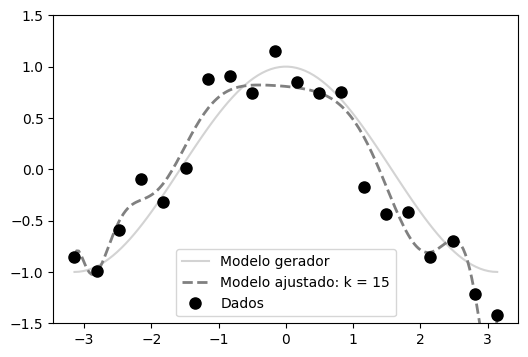

[ 0.00000000e+00 -6.26036831e-02 -7.17126826e-02 -4.94904222e-02
 -1.03646991e-01 -1.30051225e-02 -7.75190270e-02  2.57513075e-02
  4.67002599e-02 -1.16886462e-02 -8.55731784e-03  2.46243437e-03
  6.55014233e-04 -2.40493845e-04 -1.79522814e-05  8.72122379e-06]


In [13]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

np.random.seed(42)

#função para gerar os dados
def gera_dados(x, sigma):
    y = np.cos(x) + np.random.normal(0, sigma, len(x))
    return y

# gera os dados de treinamento
n_train = 20
sigma = 0.3
min_X = -np.pi; max_X = np.pi
X_train= np.linspace(min_X,max_X,n_train)
y_train = gera_dados(X_train, sigma)
X_train = X_train.reshape(len(X_train), 1)

k = 15 # grau do polinômio
# Define a matriz de atributos
poly3 = PolynomialFeatures(degree=k)
X = poly3.fit_transform(X_train)
# ajusta o modelo usando Lasso
model = Ridge(alpha = 10)
model.fit(X,y_train)

# calcula a curva de predição
xp = np.linspace(min_X,max_X,200)
Xplot = xp.reshape(len(xp), 1)
Xplot=poly3.fit_transform(Xplot)
# faz a predição
y_pred = model.predict(Xplot)

# mostra os resultados
# o modelo gerador dos dados
Xm = np.linspace(min_X,max_X,100)
yt = gera_dados(Xm, 0)
plt.figure(figsize=(6,4))
plt.plot(Xm,yt, color = 'lightgray', linestyle='-',
         label="Modelo gerador")
# modelo ajustado
plt.plot(xp, y_pred, color = 'gray',linestyle='--',
         linewidth = 2,
         label = 'Modelo ajustado: k = '+str(k))
# mostra os dados
plt.plot(X_train, y_train, color='black', marker = 'o',
         markersize=8, linestyle='none', label="Dados")
plt.ylim([-1.5, 1.5])
plt.legend(fontsize=10)
plt.show(True)

print(model.coef_)

Vamos aplicar a um conjunto de dados.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import drive
drive.mount('/content/drive/')
data = pd.read_csv('/content/drive/My Drive/dados/Advertising.csv', header=(0))

# remove nan (Not a Number)
data = data.dropna()
data = data.drop(data.columns[[0]], axis=1) # remove the first column (if useless)
# define a variável de saída
ylabel = data.columns[-1]

print('Número de observações e atributos:',data.shape)
list_labels = list(data.columns)
data.head(10)

Mounted at /content/drive/
Número de observações e atributos: (200, 4)


,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,10.6


Converte os dados para numpy para facilitar a manipulação.

In [8]:
# Converte os dados para numpy para facilitar a manipulação
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

In [9]:
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
p = 0.3 # fracao de elementos no conjunto de teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = p, random_state = 42)

In [10]:
from sklearn.preprocessing import StandardScaler
# Inicializa o StandardScaler
scaler = StandardScaler()
# Ajusta o scaler com os dados de treino e transforma os dados de treino
X_train = scaler.fit_transform(X_train)
# Transforma os dados de teste usando o scaler ajustado com os dados de treino
X_test = scaler.transform(X_test)

In [11]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

alpha = 1
# notice that we need to normalize the attributes: normalize = True
lasso = Lasso(alpha=alpha)
lasso.fit(X_train, y_train)             # Fit a ridge regression on the training data
y_pred = lasso.predict(X_test)           # Use this model to predict the test data

RSME = mean_squared_error(y_test, y_pred)
print("RSME:", RSME)          # Calculate the test MSE

from sklearn.metrics import r2_score
R2 = r2_score(y_test, y_pred)
print('R2:', R2)

RSME: 5.307012108303735
R2: 0.8056367612559759


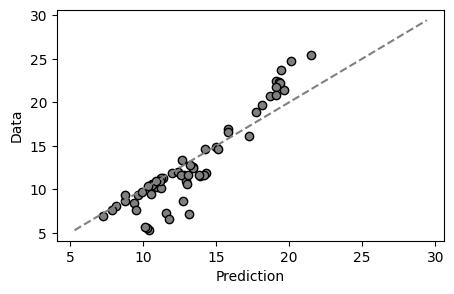

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))
l = plt.plot(y_pred, y_test, 'o', color='gray', markersize=6,
         markerfacecolor='gray',
         markeredgecolor='black')
plt.ylabel("Data", fontsize=10)
plt.xlabel("Prediction", fontsize=10)
xl = np.arange(min(y_test), 1.2*max(y_test),(max(y_test)-min(y_test))/10)
yl = xl
plt.plot(xl, yl,color = 'gray', linestyle='--')
plt.show(True)

Variando alpha, vemos que o coeficiente R2 diminui ainda mais.

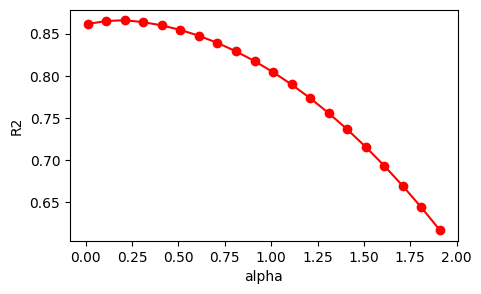

In [ ]:
vR2 = []
valpha = []
for alpha in np.arange(0.01,2,0.1):
    lasso = Lasso(alpha = alpha)
    lasso.fit(X_train, y_train)             # Fit a ridge regression on the training data
    y_pred = lasso.predict(X_test)           # Use this model to predict the test data
    r2 = r2_score(y_test, y_pred)
    vR2.append(r2)
    valpha.append(alpha)
plt.figure(figsize=(5,3))
plt.plot(valpha, vR2, '-ro')
plt.xlabel("alpha", fontsize=10)
plt.ylabel("R2", fontsize=10)
plt.show(True)

No método **Lasso**, podemos calcular os coeficientes de modo a selecionar os atributos mais importantes. Se algum atributo apresentar os respectivo coeficiente igual a zero, então esse atributo não contribui para a regressão.

Adiciona a soma dos módulos dos coeficientes.

Fórmula

$$
RSS +
\lambda
\sum_{j=1}^{p}
|\beta_j|
$$

Características

- pode zerar coeficientes
- realiza seleção automática de atributos
- produz modelos mais simples

Intuição

```text
Elimina variáveis menos importantes.
```

In [ ]:
lasso = Lasso(alpha = 0.2)
lasso.fit(X_train, y_train)             # Fit a ridge regression on the training data
print('Coeficientes: TV, radio, newspaper')
lasso.coef_

Coeficientes: TV, radio, newspaper


array([3.4972244 , 2.76701376, 0.        ])

Ou seja, vemos que a variável newspaper recebeu peso igual a zero, indicando que não é importante na predição. Portanto, não vale a pena investir em anúncios em jornais, pois o ganho nas vendas pode ser obtido com investimentos em TV e radio.

 Comparação Ridge vs Lasso

| Método | Efeito |
|---|---|
| Ridge (L2) | reduz coeficientes |
| Lasso (L1) | reduz e pode zerar coeficientes |

## Seleção de modelos

Uma das maneiras de selecionar um modelo adequado é usar um método chamado regressão stepwise, que é um método estatístico utilizado para selecionar variáveis em um modelo de regressão linear de maneira iterativa e sequencial.


In [14]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
np.random.seed(42)

n = 200 # número de observações
# gera os dados
x1 = np.random.uniform(0,5, (n, 1));
x2 = np.random.uniform(0,20, (n, 1));
x3 = np.random.uniform(0,30, (n, 1));
x4 = 3*x2 + 1
e = np.random.normal(0,5, (n, 1));
y = 4 + 2*x1 + 3*x2 + e

data = pd.DataFrame(data=np.column_stack(((x1, x2, x3, x4, y))), columns=['X1', 'X2', 'X3', 'X4', 'y'])
data.head()

,X1,X2,X3,X4,y
0,1.872701,12.840633,3.093716,39.521899,43.616012
1,4.753572,1.682799,27.076587,6.048398,14.591177
2,3.659970,3.232574,15.157571,10.697723,20.482510
3,2.993292,17.971084,24.793724,54.913251,58.723625
4,0.780093,12.128581,9.601488,37.385744,39.177683


In [15]:
df = data.to_numpy()
nrow,ncol = df.shape
y = df[:,-1]
X = df[:,0:ncol-1]

from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
p = 0.3 # fracao de elementos no conjunto de teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = p, random_state = 42)

In [16]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

model = LinearRegression()
var = ['X1', 'X2', 'X3', 'X4']
# seleciona os atributos
sfs = SequentialFeatureSelector(model, n_features_to_select='auto')
sfs.fit(X_train, y_train)
# variáveis selecionadas
var_sel = sfs.get_support()
print('Variáveis selecionadas:')
for i in range(len(var)):
    if var_sel[i] == True:
        print(var[i])
X_train_sel = X_train[:,var_sel]
X_test_sel = X_test[:,var_sel]

Variáveis selecionadas:
X1
X2


In [17]:
from sklearn.linear_model import LinearRegression

# modelo de regressão linear múltipla
model = LinearRegression()
model.fit(X_train_sel, y_train)
y_pred = model.predict(X_test_sel)

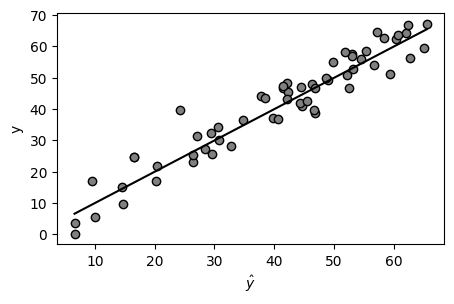

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# mostra os resultados
plt.figure(figsize=(5,3))
plt.plot(y_pred, y_test, 'o', color='gray', markersize=6,
         markerfacecolor='gray',
         markeredgecolor='black')
# mostra a linha x = y
plt.plot([min(y_pred),max(y_pred)],[min(y_pred),max(y_pred)],
         color = 'black', linestyle='-')
plt.ylabel("y", fontsize=10)
plt.xlabel(r"$\hat{y}$", fontsize=10)
plt.show(True)

## Ajuste de modelos

Para selecionar os valores do hiperparâmetros de um modelo, podemos usar o método de validação cruzada (cross validation).

https://en.wikipedia.org/wiki/Cross-validation_(statistics)

In [1]:
import random
random.seed(42) # define the seed (important to reproduce the results)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive/')
data = pd.read_csv('/content/drive/My Drive/dados/Vehicle.csv', header=(0))

# armazena o nome das classes
classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)  #name of the clases
features_names = data.columns

print("Número de linhas e colunas na matriz de atributos:", data.shape)
attributes = list(data.columns[0:-1])
# mostra os dados
data.head(10)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Número de linhas e colunas na matriz de atributos: (846, 19)


,Comp,Circ,D.Circ,Rad.Ra,Pr.Axis.Ra,Max.L.Ra,Scat.Ra,Elong,Pr.Axis.Rect,Max.L.Rect,Sc.Var.Maxis,Sc.Var.maxis,Ra.Gyr,Skew.Maxis,Skew.maxis,Kurt.maxis,Kurt.Maxis,Holl.Ra,Class
0,95,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197,van
1,91,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199,van
2,104,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196,saab
3,93,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207,van
4,85,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183,bus
5,107,57,106,172,50,6,255,26,28,169,280,957,264,85,5,9,181,183,bus
6,97,43,73,173,65,6,153,42,19,143,176,361,172,66,13,1,200,204,bus
7,90,43,66,157,65,9,137,48,18,146,162,281,164,67,3,3,193,202,van
8,86,34,62,140,61,7,122,54,17,127,141,223,112,64,2,14,200,208,van
9,93,44,98,197,62,11,183,36,22,146,202,505,152,64,4,14,195,204,saab


Vamos selecionar o melhor número de vizinhos no método k-neighbours.



k: 1 acurácia média: 0.6773109243697479
[0.70588235 0.68067227 0.65254237 0.6779661  0.66949153]
k: 2 acurácia média: 0.6317333713146276
[0.65546218 0.62184874 0.65254237 0.61016949 0.61864407]
k: 3 acurácia média: 0.6756587380714998
[0.66386555 0.69747899 0.68644068 0.69491525 0.63559322]
k: 4 acurácia média: 0.6790770545506338
[0.66386555 0.68067227 0.70338983 0.70338983 0.6440678 ]
k: 5 acurácia média: 0.6758154109101268
[0.61344538 0.65546218 0.75423729 0.65254237 0.70338983]
k: 6 acurácia média: 0.6689360489958696
[0.65546218 0.67226891 0.70338983 0.65254237 0.66101695]
k: 7 acurácia média: 0.6690357498931776
[0.6302521  0.63865546 0.6779661  0.66949153 0.72881356]
k: 8 acurácia média: 0.6757869249394672
[0.62184874 0.66386555 0.68644068 0.68644068 0.72033898]
k: 9 acurácia média: 0.6741204956558894
[0.62184874 0.64705882 0.71186441 0.68644068 0.70338983]
k: 10 acurácia média: 0.6639510041304657
[0.6302521  0.63865546 0.6779661  0.68644068 0.68644068]
k: 11 acurácia média: 0.66566

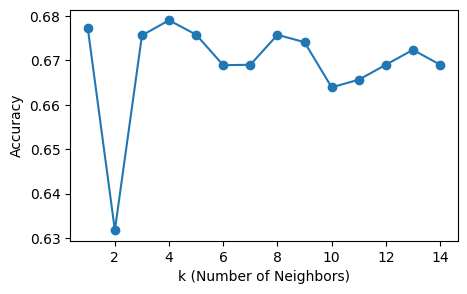

Best k: 4
Test accuracy: 0.7165354330708661


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target variable (y)
X = data.drop(columns=data.columns[-1])
y = data[data.columns[-1]]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Inicializa o StandardScaler
scaler = StandardScaler()
# Ajusta o scaler com os dados de treino e transforma os dados de treino
scaler.fit(X_train)
X_train = scaler.transform(X_train)
# Transforma os dados de teste usando o scaler ajustado com os dados de treino
X_test = scaler.transform(X_test)

# Find the best k using cross-validation
k_range = range(1, 15) # Test k values from 1 to 30
scores = []
for k in k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    cv_scores = cross_val_score(knn_cv, X_train, y_train, cv=5) # 5-fold cross-validation
    print('k:', k, 'acurácia média:', np.mean(cv_scores))
    print(cv_scores)
    scores.append(np.mean(cv_scores))

plt.figure(figsize=(5, 3))
plt.plot(k_range, scores, marker='o')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.show()

# Find the best k
best_k = k_range[np.argmax(scores)]
print("Best k:", best_k)

# Evaluate the model with the best k on the test set
knn = KNeighborsClassifier()
knn.n_neighbors = best_k
knn.fit(X_train, y_train)
accuracy = knn.score(X_test, y_test)
print("Test accuracy:", accuracy)

Podemos usar o método grid_search que faz essa tarefa de forma automática.

<img src="https://scikit-learn.org/1.5/_images/grid_search_workflow.png" width=400 />


In [4]:
from sklearn.model_selection import GridSearchCV

# Define a variação dos hiperparâmetros
param_grid = {'n_neighbors': range(1, 15),
              'metric': ['minkowski', 'euclidean', 'cosine']
              }

# chama o método grid_search
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# mostra os melhores parâmetros
print("Best hyperparameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

# Usa os melhores hiperâmetros na predição
best_model = grid_search.best_estimator_
accuracy = best_model.score(X_test, y_test)
print("Test accuracy:", accuracy)

Best hyperparameters: {'metric': 'cosine', 'n_neighbors': 1}
Best score: 0.692536675687224
Test accuracy: 0.7283464566929134


---

#### Relevância para Data Science

**Generalização**

O conceito MAIS importante em produção.

Um modelo só é útil se funcionar bem em dados novos.


**Redução de Dimensionalidade**

Lasso e Stepwise ajudam a:

- remover ruído
- simplificar modelos
- acelerar treinamento


**Ajuste de Hiperparâmetros**

Regularização depende do parâmetro:

$$
\lambda
$$


*Efeito de $\lambda$*

| Valor | Efeito |
|---|---|
| pequeno | pouca regularização |
| grande | forte penalização |


*Intuição*

```text
λ controla o quanto
punimos complexidade.
```

**Validação Robusta**

Precisamos avaliar o modelo corretamente.



**Holdout**

Divisão simples:

- treino
- teste

**k-fold Cross-Validation**

O dataset é dividido em:

$$
k
$$

partes.

O modelo é treinado:

$$
k
$$

vezes.

*Processo*

- uma parte vira teste
- as demais viram treino
- repete-se o processo


**Resultado Final**

A métrica final é:

> a média das avaliações.

Vantagem

Reduz dependência de uma divisão "sortuda".

**Erro Quadrático Médio (MSE)**

Principal métrica para regressão.

Fórmula

$$
MSE =
\frac{1}{n}
\sum_{i=1}^{n}
(y_i - \hat{y}_i)^2
$$

Interpretação

Quanto menor:

$$
MSE
$$

melhor o modelo.


---

**Resumo Mental**

```text
Underfitting:
modelo simples demais

Overfitting:
modelo complexo demais

Bias:
erro sistemático

Variância:
sensibilidade aos dados

Regularização:
controla complexidade

Ridge:
encolhe coeficientes

Lasso:
remove variáveis
```

*Intuição Final*

Grande parte do trabalho em Machine Learning consiste em:

- controlar complexidade
- evitar overfitting
- encontrar equilíbrio entre bias e variância
- garantir boa generalização

Regularização e seleção de atributos são ferramentas essenciais para construir modelos robustos em produção.